season,BRA_24-29,BRA_30+,BRA_<=23,EST_24-29,EST_30+,EST_<=23
2014,45.67,21.42,24.07,4.6,3.23,1.01
2015,43.75,23.33,26.72,3.04,2.53,0.64
2016,37.89,29.21,24.98,5.01,1.57,1.34
2017,41.0,27.27,21.27,6.85,2.41,1.2
2018,36.85,30.42,23.12,5.77,3.18,0.66
2019,35.32,33.38,20.86,5.82,3.8,0.82
2020,34.79,27.96,27.75,4.78,2.8,1.92
2021,37.29,29.95,23.85,4.13,2.64,2.14
2022,36.32,30.58,19.58,6.13,5.16,2.22
2023,34.22,29.0,17.77,8.82,7.25,2.95


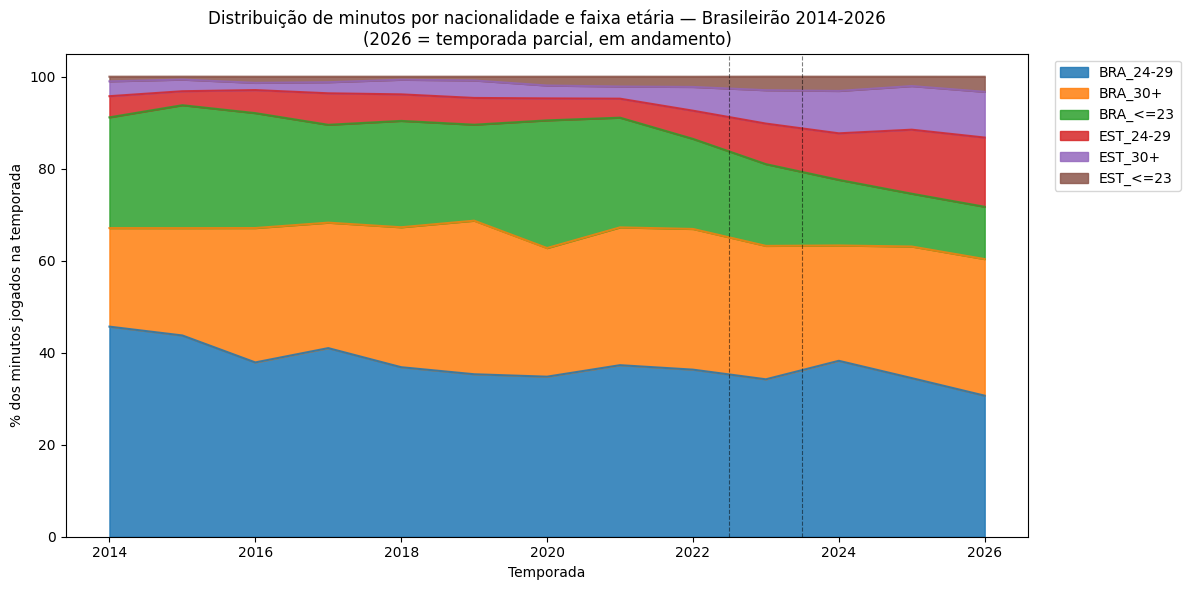

season,jogadores_estrangeiros,pct_jogadores_estrangeiros,pct_minutos_estrangeiros,intensidade_uso_estrangeiros,jogadores_bra_u23,pct_jogadores_bra_u23,pct_minutos_bra_u23,intensidade_uso_bra_u23,jogadores_bra_24_29,pct_jogadores_bra_24_29,pct_minutos_bra_24_29,intensidade_uso_bra_24_29,jogadores_bra_veteranos,pct_jogadores_bra_veteranos,pct_minutos_bra_veteranos,intensidade_uso_bra_veteranos
2014,62,8.52,8.84,1.04,276,37.91,24.07,0.63,264,36.26,45.67,1.26,126,17.31,21.42,1.24
2015,55,7.72,6.2,0.8,254,35.67,26.72,0.75,269,37.78,43.75,1.16,134,18.82,23.33,1.24
2016,73,10.15,7.92,0.78,256,35.61,24.98,0.7,246,34.21,37.89,1.11,143,19.89,29.21,1.47
2017,73,10.22,10.46,1.02,255,35.71,21.27,0.6,235,32.91,41.0,1.25,151,21.15,27.27,1.29
2018,75,10.46,9.59,0.92,247,34.45,23.12,0.67,233,32.5,36.85,1.13,161,22.45,30.42,1.36
2019,71,10.23,10.44,1.02,218,31.41,20.86,0.66,220,31.7,35.32,1.11,185,26.66,33.38,1.25
2020,82,11.14,9.5,0.85,287,38.99,27.75,0.71,210,28.53,34.79,1.22,156,21.2,27.96,1.32
2021,77,10.75,8.91,0.83,262,36.59,23.85,0.65,222,31.01,37.29,1.2,155,21.65,29.95,1.38
2022,104,13.9,13.51,0.97,244,32.62,19.58,0.6,229,30.61,36.32,1.19,171,22.86,30.58,1.34
2023,132,17.89,19.01,1.06,234,31.71,17.77,0.56,211,28.59,34.22,1.2,161,21.82,29.0,1.33


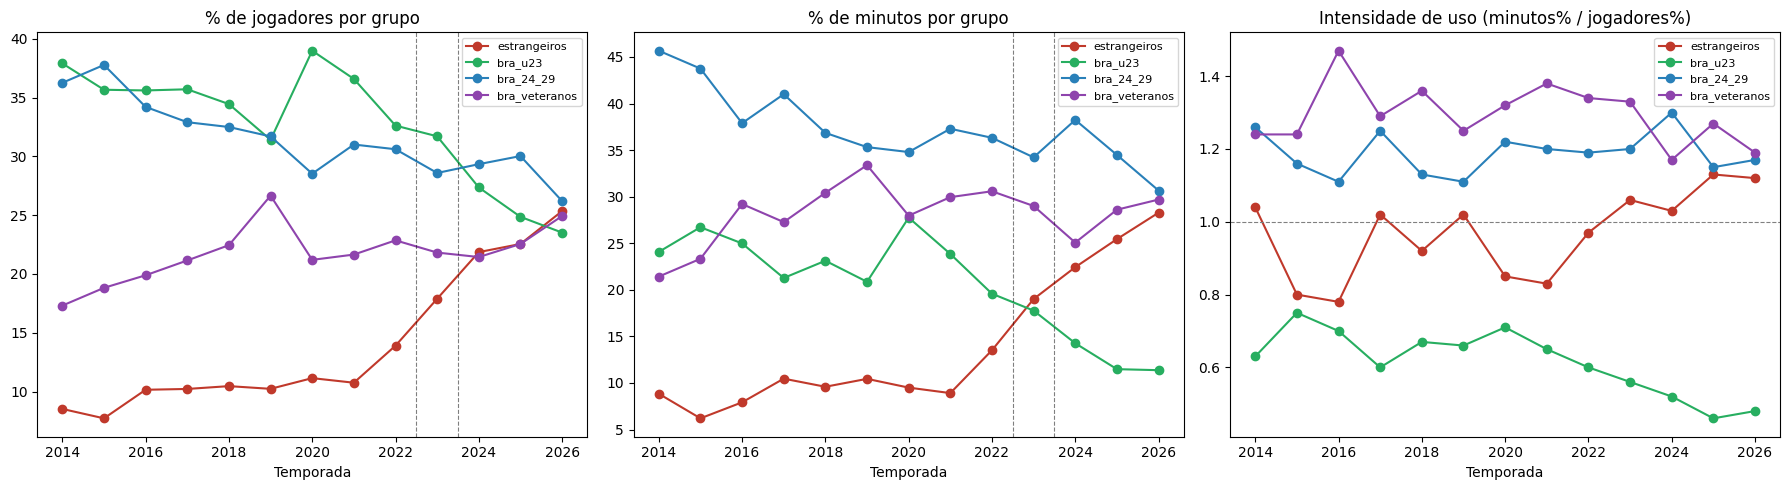

In [0]:
import matplotlib.pyplot as plt
import pandas as pd
from pyspark.sql import functions as F


gold = spark.table("estudo_estrangeiros.gold.age_nationality_minutes")
pdf = gold.toPandas()

# marca 2026 como parcial - não deve ser comparada ingenuamente com temporadas completas
pdf["season_label"] = pdf["season"].apply(lambda s: f"{s}*" if s == 2026 else str(s))

# obs: as ~3 linhas sem nacionalidade informada (ver Qualidade de Dados) caem aqui
# como "EST" por padrão do pandas - impacto irrelevante dado o volume (<0.05% do total)
pdf["group"] = pdf.apply(
    lambda r: f"{'BRA' if r['is_brazilian'] else 'EST'}_{r['age_band']}", axis=1
)

matrix = (
    pdf.pivot_table(index="season", columns="group", values="pct_of_season_minutes", aggfunc="sum")
    .fillna(0)
    .sort_index()
)

display(spark.createDataFrame(matrix.reset_index()))

# gráfico de área empilhada - evolução da distribuição de minutos
def marcar_mudanca_limite(ax):
    ax.axvline(x=2022.5, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.axvline(x=2023.5, color="black", linestyle="--", linewidth=0.8, alpha=0.5)

fig, ax = plt.subplots(figsize=(12, 6))
matrix.plot.area(ax=ax, alpha=0.85)
marcar_mudanca_limite(ax)
ax.set_ylabel("% dos minutos jogados na temporada")
ax.set_xlabel("Temporada")
ax.set_title("Distribuição de minutos por nacionalidade e faixa etária — Brasileirão 2014-2026\n(2026 = temporada parcial, em andamento)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

# --- Perguntas 1 e 2 isoladas: tendência simples ano a ano ---
silver_all = spark.table("estudo_estrangeiros.silver.player_season_club")  # sem filtro de season

total_por_temporada = (
    silver_all.groupBy("season")
    .agg(
        F.countDistinct("player_id").alias("total_jogadores"),
        F.sum("minutes").alias("total_minutos"),
    )
)

def resumo_grupo(nome, condicao):
    return (
        silver_all.filter(condicao)
        .groupBy("season")
        .agg(
            F.countDistinct("player_id").alias(f"jogadores_{nome}"),
            F.sum("minutes").alias(f"minutos_{nome}"),
        )
        .join(total_por_temporada, "season")
        .withColumn(f"pct_jogadores_{nome}", F.round(F.col(f"jogadores_{nome}") / F.col("total_jogadores") * 100, 2))
        .withColumn(f"pct_minutos_{nome}", F.round(F.col(f"minutos_{nome}") / F.col("total_minutos") * 100, 2))
        .withColumn(f"intensidade_uso_{nome}", F.round(F.col(f"pct_minutos_{nome}") / F.col(f"pct_jogadores_{nome}"), 2))
        .select("season", f"jogadores_{nome}", f"pct_jogadores_{nome}", f"pct_minutos_{nome}", f"intensidade_uso_{nome}")
    )

grupos_def = {
    "estrangeiros": ~F.col("is_brazilian"),
    "bra_u23": (F.col("is_brazilian")) & (F.col("age_band") == "<=23"),
    "bra_24_29": (F.col("is_brazilian")) & (F.col("age_band") == "24-29"),
    "bra_veteranos": (F.col("is_brazilian")) & (F.col("age_band") == "30+"),
}

resumo_q1_q2_q3 = total_por_temporada.select("season")
for nome, condicao in grupos_def.items():
    resumo_q1_q2_q3 = resumo_q1_q2_q3.join(resumo_grupo(nome, condicao), "season")
resumo_q1_q2_q3 = resumo_q1_q2_q3.orderBy("season")
display(resumo_q1_q2_q3)


# --- gráficos: % jogadores, % minutos, intensidade de uso, um por grupo ---
resumo_pdf = resumo_q1_q2_q3.toPandas().set_index("season")
grupos = list(grupos_def.keys())
cores = {"estrangeiros": "#c0392b", "bra_u23": "#27ae60", "bra_24_29": "#2980b9", "bra_veteranos": "#8e44ad"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for grupo in grupos:
    axes[0].plot(resumo_pdf.index, resumo_pdf[f"pct_jogadores_{grupo}"], marker="o", label=grupo, color=cores[grupo])
    axes[1].plot(resumo_pdf.index, resumo_pdf[f"pct_minutos_{grupo}"], marker="o", label=grupo, color=cores[grupo])
    axes[2].plot(resumo_pdf.index, resumo_pdf[f"intensidade_uso_{grupo}"], marker="o", label=grupo, color=cores[grupo])

marcar_mudanca_limite(axes[0])
marcar_mudanca_limite(axes[1])

axes[0].set_title("% de jogadores por grupo")
axes[1].set_title("% de minutos por grupo")
axes[2].set_title("Intensidade de uso (minutos% / jogadores%)")
axes[2].axhline(1, color="gray", linestyle="--", linewidth=0.8)
for ax in axes:
    ax.set_xlabel("Temporada")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()





In [0]:
### Análise - Uso de estrangeiros/jovens x desemepnho do clube

club_perf = spark.table("estudo_estrangeiros.gold.club_performance").toPandas()
club_perf_completo = club_perf[club_perf["season"] != 2026]

colunas = ["pct_minutes_foreign", "pct_minutes_brazilian_u23", "points_per_match", "goal_diff", "goals_for", "position"]
corr_pearson = club_perf_completo[colunas].corr(method="pearson").round(2)
corr_spearman = club_perf_completo[colunas].corr(method="spearman").round(2)

print("=== Correlação de Pearson (valores absolutos) ===")
display(spark.createDataFrame(corr_pearson.reset_index()))
print("=== Correlação de Spearman (por colocação/ranking) ===")
display(spark.createDataFrame(corr_spearman.reset_index()))



=== Correlação de Pearson (valores absolutos) ===


index,pct_minutes_foreign,pct_minutes_brazilian_u23,points_per_match,goal_diff,goals_for,position
pct_minutes_foreign,1.0,-0.23,0.25,0.23,0.29,-0.24
pct_minutes_brazilian_u23,-0.23,1.0,-0.07,-0.05,-0.09,0.04
points_per_match,0.25,-0.07,1.0,0.95,0.84,-0.95
goal_diff,0.23,-0.05,0.95,1.0,0.85,-0.9
goals_for,0.29,-0.09,0.84,0.85,1.0,-0.8
position,-0.24,0.04,-0.95,-0.9,-0.8,1.0


=== Correlação de Spearman (por colocação/ranking) ===


index,pct_minutes_foreign,pct_minutes_brazilian_u23,points_per_match,goal_diff,goals_for,position
pct_minutes_foreign,1.0,-0.17,0.26,0.23,0.3,-0.26
pct_minutes_brazilian_u23,-0.17,1.0,-0.02,-0.03,-0.08,0.02
points_per_match,0.26,-0.02,1.0,0.94,0.81,-0.98
goal_diff,0.23,-0.03,0.94,1.0,0.82,-0.92
goals_for,0.3,-0.08,0.81,0.82,1.0,-0.79
position,-0.26,0.02,-0.98,-0.92,-0.79,1.0


season,pct_gols_estrangeiros,indice_producao_estrangeiros,pct_gols_bra_u23,indice_producao_bra_u23,pct_gols_bra_24_29,indice_producao_bra_24_29,pct_gols_bra_veteranos,indice_producao_bra_veteranos
2014,15.5,1.71,26.32,1.04,37.26,0.88,20.91,0.91
2015,8.5,1.23,25.37,1.0,38.23,0.92,27.9,1.09
2016,12.75,1.54,25.95,1.06,31.77,0.89,29.53,0.94
2017,12.94,1.26,21.24,1.0,38.05,0.97,27.77,0.94
2018,13.5,1.61,23.25,0.94,37.5,1.06,25.75,0.78
2019,14.55,1.34,22.54,1.12,33.69,0.99,29.23,0.83
2020,9.65,1.1,29.39,1.05,34.16,0.98,26.79,0.95
2021,11.46,1.33,22.8,0.96,35.0,0.99,30.73,0.94
2022,20.79,1.48,19.44,1.0,33.45,0.95,26.33,0.85
2023,24.54,1.31,20.3,1.02,30.29,0.87,24.86,0.94


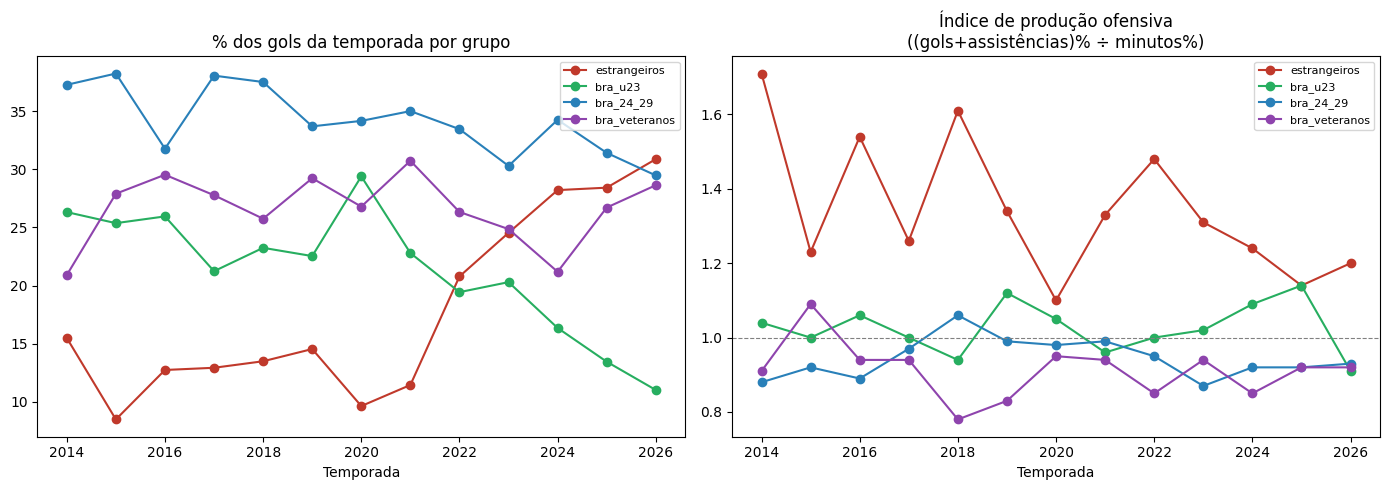

In [0]:
### Anaálise - Produção Ofensiva

silver_all = spark.table("estudo_estrangeiros.silver.player_season_club")

totais = (
    silver_all.groupBy("season")
    .agg(
        F.sum("minutes").alias("total_minutos"),
        F.sum("goals").alias("total_gols"),
        F.sum("assists").alias("total_assist"),
    )
)

grupos_def = {
    "estrangeiros": ~F.col("is_brazilian"),
    "bra_u23": (F.col("is_brazilian")) & (F.col("age_band") == "<=23"),
    "bra_24_29": (F.col("is_brazilian")) & (F.col("age_band") == "24-29"),
    "bra_veteranos": (F.col("is_brazilian")) & (F.col("age_band") == "30+"),
}

def producao_grupo(nome, condicao):
    return (
        silver_all.filter(condicao)
        .groupBy("season")
        .agg(F.sum("minutes").alias("m"), F.sum("goals").alias("g"), F.sum("assists").alias("a"))
        .join(totais, "season")
        .withColumn(f"pct_gols_{nome}", F.round(F.col("g") / F.col("total_gols") * 100, 2))
        .withColumn(f"pct_minutos_{nome}", F.col("m") / F.col("total_minutos") * 100)
        .withColumn(f"pct_ga_{nome}", (F.col("g") + F.col("a")) / (F.col("total_gols") + F.col("total_assist")) * 100)
        .withColumn(f"indice_producao_{nome}", F.round(F.col(f"pct_ga_{nome}") / F.col(f"pct_minutos_{nome}"), 2))
        .select("season", f"pct_gols_{nome}", f"indice_producao_{nome}")
    )

producao = totais.select("season")
for nome, cond in grupos_def.items():
    producao = producao.join(producao_grupo(nome, cond), "season")
producao = producao.orderBy("season")
display(producao)

prod_pdf = producao.toPandas().set_index("season")
cores = {"estrangeiros": "#c0392b", "bra_u23": "#27ae60", "bra_24_29": "#2980b9", "bra_veteranos": "#8e44ad"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for grupo in grupos_def:
    axes[0].plot(prod_pdf.index, prod_pdf[f"pct_gols_{grupo}"], marker="o", label=grupo, color=cores[grupo])
    axes[1].plot(prod_pdf.index, prod_pdf[f"indice_producao_{grupo}"], marker="o", label=grupo, color=cores[grupo])

axes[0].set_title("% dos gols da temporada por grupo")
axes[1].set_title("Índice de produção ofensiva\n((gols+assistências)% ÷ minutos%)")
axes[1].axhline(1, color="gray", linestyle="--", linewidth=0.8)
for ax in axes:
    ax.set_xlabel("Temporada")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()




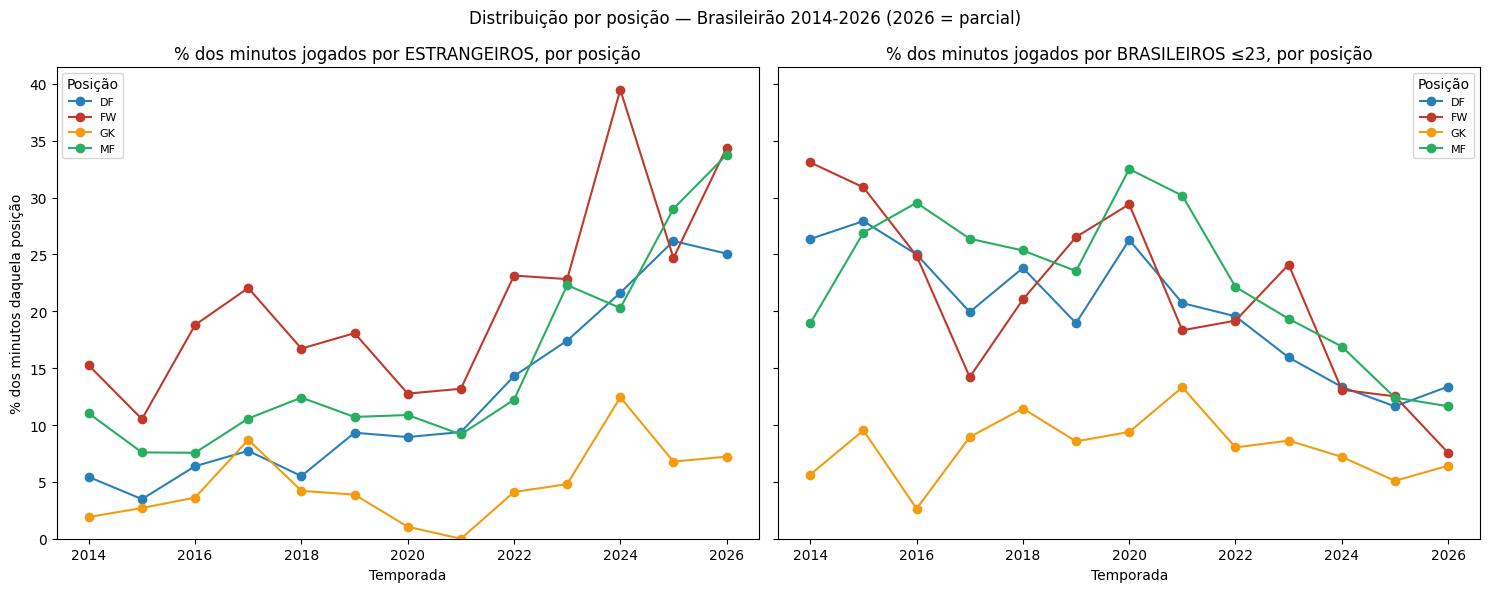

season,position_primary,min_estrangeiros,min_bra_u23,min_total,pct_estrangeiros,pct_bra_u23
2014,DF,16938,82234,311985,5.43,26.36
2014,FW,26365,57232,172981,15.24,33.09
2014,GK,1305,3860,68390,1.91,5.64
2014,MF,21768,37409,197481,11.02,18.94
2025,DF,70111,31180,267795,26.18,11.64
2025,FW,23291,11808,94340,24.69,12.52
2025,GK,4635,3484,68397,6.78,5.09
2025,MF,92772,39647,319529,29.03,12.41
2026,DF,49304,26321,196682,25.07,13.38
2026,FW,19913,4378,57911,34.39,7.56


In [0]:
#Análise - Variação por posição
por_posicao = (
    spark.table("estudo_estrangeiros.silver.player_season_club")
    .filter("position_primary IS NOT NULL")
    .groupBy("season", "position_primary")
    .agg(
        F.sum(F.when(~F.col("is_brazilian"), F.col("minutes")).otherwise(0)).alias("min_estrangeiros"),
        F.sum(F.when((F.col("is_brazilian")) & (F.col("age_band") == "<=23"), F.col("minutes")).otherwise(0)).alias("min_bra_u23"),
        F.sum("minutes").alias("min_total"),
    )
    .withColumn("pct_estrangeiros", F.round(F.col("min_estrangeiros") / F.col("min_total") * 100, 2))
    .withColumn("pct_bra_u23", F.round(F.col("min_bra_u23") / F.col("min_total") * 100, 2))
    .orderBy("season", "position_primary")
    .toPandas()
)

pivot_est = por_posicao.pivot(index="season", columns="position_primary", values="pct_estrangeiros").sort_index()
pivot_u23 = por_posicao.pivot(index="season", columns="position_primary", values="pct_bra_u23").sort_index()
cores_pos = {"GK": "#f39c12", "DF": "#2980b9", "MF": "#27ae60", "FW": "#c0392b"}

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
for pos in pivot_est.columns:
    axes[0].plot(pivot_est.index, pivot_est[pos], marker="o", label=pos, color=cores_pos.get(pos))
    axes[1].plot(pivot_u23.index, pivot_u23[pos], marker="o", label=pos, color=cores_pos.get(pos))

axes[0].set_title("% dos minutos jogados por ESTRANGEIROS, por posição")
axes[1].set_title("% dos minutos jogados por BRASILEIROS ≤23, por posição")
axes[0].set_ylabel("% dos minutos daquela posição")
axes[0].set_ylim(bottom=0)
for ax in axes:
    ax.set_xlabel("Temporada")
    ax.legend(title="Posição", fontsize=8)
plt.suptitle("Distribuição por posição — Brasileirão 2014-2026 (2026 = parcial)")
plt.tight_layout()
plt.show()

display(spark.createDataFrame(
    por_posicao[por_posicao["season"].isin([2014, 2025, 2026])]
))



